<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/5_manual_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 5 — Manual Hyperparameter Tuning**

Notebooks 3 and 4 found the best architecture and regularization:
- 4 conv layers, GAP, 32→64→128→256 filters
- dropout=0.2, no L2, basic augmentation
- val accuracy: 13.41%

*This notebook asks: how much does hyperparameter tuning
actually matter on top of good architecture choices?*

Three hyperparameters tested one at a time:

| Experiment | What changes | Question |
|---|---|---|
| H | Learning rate: 0.01, 0.001, 0.0001 | Most impactful single param? |
| I | Batch size: 16, 32, 64, 128 | Speed vs stability tradeoff? |
| J | Optimizer: Adam vs SGD vs RMSprop | Which converges best? |
| K | Dense units: 64 vs 128 vs 256 | Does head size matter? |

All experiments use:
- 4 conv layers, GAP, 32→64→128→256 filters
- dropout=0.2, basic augmentation, no L2
- 128×128 input, seed=42, 10 epochs

###**Baseline to beat: 13.41% val accuracy**

In [ ]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                      GlobalAveragePooling2D,
                                      Dense, Dropout)
import matplotlib.pyplot as plt
import pandas as pd
import time
import kagglehub

path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")

Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.


In [ ]:
def load_data(img_size=128, batch_size=32):
    def norm(image, label):
        return tf.cast(image/255., tf.float32), label

    def basic_aug(image, label):
        image = tf.image.random_flip_left_right(image)
        return image, label

    train = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(img_size, img_size),
        validation_split=0.2,
        subset='training',
        seed=42
    ).map(norm).map(basic_aug).prefetch(tf.data.AUTOTUNE)

    val = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(img_size, img_size),
        validation_split=0.2,
        subset='validation',
        seed=42
    ).map(norm).prefetch(tf.data.AUTOTUNE)

    return train, val

In [ ]:
def build_model(dense_units=128,lr =0.001,optimizer='adam'):
  if optimizer=='adam':
    opt =keras.optimizers.Adam(learning_rate=lr)
  elif optimizer=='sgd':
    opt =keras.optimizers.SGD(learning_rate=lr,momentum=0.9)
  elif optimizer=='rmsprop':
    opt =keras.optimizers.RMSprop(learning_rate=lr)


  model = Sequential([
        keras.Input(shape=(128,128,3)),

        # block 1 — (3×3×3+1)×32 = 896 params
        Conv2D(32, (3,3), padding='valid', activation='relu'),
        MaxPooling2D((2,2)),


        # block 2 — (3×3×32+1)×64 = 18,496 params
        Conv2D(64, (3,3), padding='valid', activation='relu'),
        MaxPooling2D((2,2)),


        # block 3 — (3×3×64+1)×128 = 73,856 params
        Conv2D(128, (3,3), padding='valid', activation='relu'),
        MaxPooling2D((2,2)),


        # block 4 — (3×3×128+1)×256 = 295,168 params
        Conv2D(256, (3,3), padding='valid', activation='relu'),
        MaxPooling2D((2,2)),


        GlobalAveragePooling2D(),
        Dense(dense_units, activation='relu'),
        Dropout(0.2),
        Dense(120, activation='softmax')
    ])
  model.compile(optimizer=opt,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  return model

def train_model(model, train_d, epochs=10):
    start = time.time()
    history = model.fit(
        train_d,
        validation_data=val_data,
        epochs=epochs,
        verbose=1
    )
    time_taken = round((time.time()-start)/60, 1)
    val_acc = max(history.history['val_accuracy'])
    print(f"val acc: {val_acc:.2%} | time: {time_taken} mins")
    return history, val_acc, time_taken


In [ ]:
def plot_comparison(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    colors = ['royalblue','tomato','seagreen','orange']
    for i, (history, label) in enumerate(zip(histories, labels)):
        axes[0].plot(history.history['accuracy'],
                     color=colors[i], label=f'{label} train')
        axes[0].plot(history.history['val_accuracy'],
                     color=colors[i], label=f'{label} val',
                     linestyle='--')
        axes[1].plot(history.history['loss'],
                     color=colors[i], label=f'{label} train')
        axes[1].plot(history.history['val_loss'],
                     color=colors[i], label=f'{label} val',
                     linestyle='--')
    axes[0].set_title('Accuracy')
    axes[1].set_title('Loss')
    for ax in axes:
        ax.legend(fontsize=7)
        ax.set_xlabel('Epoch')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
train_data, val_data = load_data(batch_size=32)


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


##**Experiment H — Learning Rate: 0.01 vs 0.001 vs 0.0001**


**Hypothesis:** learning rate will be the most impactful
hyperparameter. Too high (0.01) will cause unstable training
with oscillating loss. Too low (0.0001) will converge too
slowly to reach good accuracy in 10 epochs. 0.001 (Adam default)
will perform best.

In [ ]:
lr_history = {}
lr_acc ={}

for lr in[0.01,0.001,0.0001]:
  tf.keras.backend.clear_session()
  print(f'Training lr={lr}')
  model =build_model(lr=lr)
  h,acc,t =train_model(model,train_data)
  lr_history[lr] = h
  lr_acc[lr] = acc


Training lr=0.01
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 75s 133ms/step - accuracy: 0.0117 - loss: 4.7930 - val_accuracy: 0.0117 - val_loss: 4.7879
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0115 - loss: 4.7853 - val_accuracy: 0.0117 - val_loss: 4.7891
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0114 - loss: 4.7853 - val_accuracy: 0.0117 - val_loss: 4.7892
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.0116 - loss: 4.7853 - val_accuracy: 0.0117 - val_loss: 4.7894
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0117 - loss: 4.7852 - val_accuracy: 0.0117 - val_loss: 4.7893
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.0113 - loss: 4.7853 - val_accuracy: 0.0117 - val_loss: 4.7891
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.0115 - loss: 4.7853 - val_accuracy: 0.0117 - val_loss: 4.7891
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.0116

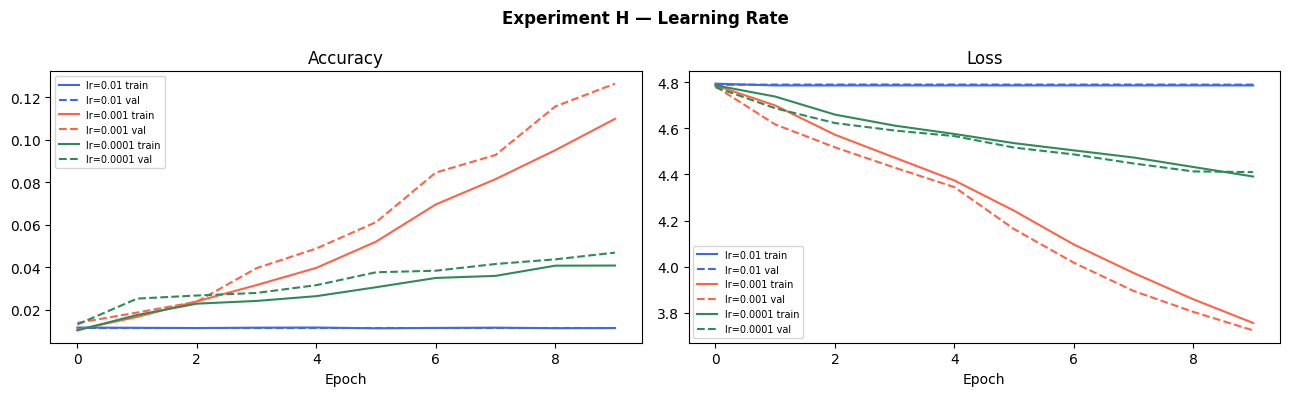

In [ ]:
plot_comparison(
    list(lr_history.values()),
    [f'lr={lr}' for lr in lr_history.keys()],
    'Experiment H — Learning Rate'
)

## **Experiment H — Results**

| Learning Rate | Val Accuracy | Train Accuracy | Behaviour |
|---|---|---|---|
| 0.01 | 1.17% | 1.17% | dead — not learning |
| 0.001 | 12.63% | 10.98% | smooth convergence |
| 0.0001 | 4.69% | 4.08% | too slow |

**Result: confirmed — 0.001 wins, but 0.01 killed learning
rather than oscillating as predicted**

## What I observed

lr=0.01 is completely dead — loss stuck at 4.78 all 10
epochs. This is the same dead model pattern seen multiple
times now. With Adam, 0.01 is too large — the optimizer
overshoots every minimum and never settles.

lr=0.001 converges smoothly — both curves drop steadily,
val accuracy higher than train (dropout effect).
Clear winner at 12.63%.

lr=0.0001 learns but too slowly, still improving at
epoch 10, never plateauing. Given more epochs it would
likely surpass 0.001 eventually but 10 epochs isn't enough.

## The dead model pattern — full picture

This is now the fourth time we've seen loss stuck at 4.78:

| Experiment | Cause |
|---|---|
| A | BatchNorm at batch=32 |
| D | 64→128→256→512 filters |
| F | L2=1e-3 |
| H | lr=0.01 with Adam |

All share the same root cause -->the optimizer cannot find
a useful gradient direction.

Too much constraint, too much
capacity, or too large a step size all produce the same
symptom: random guessing across 120 classes.

-------------------------------
##**Decision: lr=0.001 confirmed as default**
**Current best: 13.41% val accuracy (from notebook 4)**

## *Important note*

lr=0.001 gave 12.63% here vs 13.41% in notebook 4 using
the same learning rate. This is training variance again —
same lr, slightly different result across runs.

The key finding stands: 0.001 is the only lr that learns
properly. But it confirms that learning rate alone is not
enough — the combination of architecture + regularization
+ augmentation from notebook 4 together produced the better
result, not any single hyperparameter in isolation.

This is exactly the answer to the notebook 5 question:
"how much does hyperparameter tuning actually matter
on top of good architecture choices?"

So far —>less than expected. Architecture and regularization
decisions from notebooks 3 and 4 had more impact.

## **Experiment I — Batch Size: 16 vs 32 vs 64 vs 128**

**Hypothesis:** smaller batches will generalize better due to
noisier gradient updates acting as regularization, but will
train slower. Larger batches will be faster but may overfit
more. Batch size will have less impact on accuracy than
learning rate.

In [ ]:

batch_history = {}
batch_acc = {}
batch_times = {}

for bs in [16, 32, 64, 128]:
    tf.keras.backend.clear_session()
    print(f"Training batch_size={bs}...")
    train_d, _ = load_data(batch_size=bs)
    model = build_model()
    h, acc, t = train_model(model, train_d)
    batch_history[bs] = h
    batch_acc[bs] = acc
    batch_times[bs] = t
    print(f"  time: {t} mins")


Training batch_size=16...
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Epoch 1/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - accuracy: 0.0109 - loss: 4.7858 - val_accuracy: 0.0117 - val_loss: 4.7844
Epoch 2/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.0119 - loss: 4.7813 - val_accuracy: 0.0117 - val_loss: 4.7851
Epoch 3/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.0128 - loss: 4.7749 - val_accuracy: 0.0168 - val_loss: 4.7547
Epoch 4/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.0163 - loss: 4.6915 - val_accuracy: 0.0151 - val_loss: 4.6471
Epoch 5/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.0206 - loss: 4.6204 - val_accuracy: 0.0219 - val_loss: 4.5910
Epoch 6/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.0258 - loss: 4.5403 - val_accuracy: 0.0292 - val_loss: 4.5228
Epoch 7/10
1029/1029 ━━━━━━━━

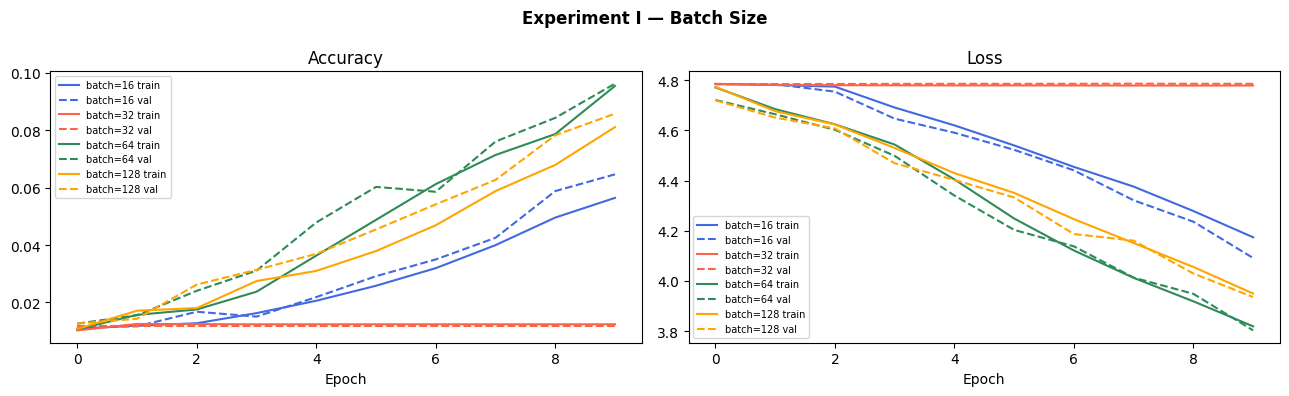

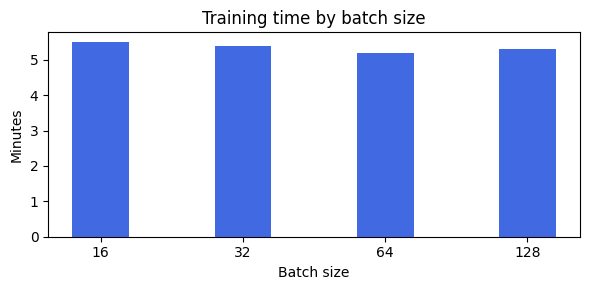

In [ ]:
plot_comparison(
    list(batch_history.values()),
    [f'batch={bs}' for bs in batch_history.keys()],
    'Experiment I — Batch Size'
)

# time comparison
plt.figure(figsize=(6,3))
plt.bar([str(bs) for bs in batch_times.keys()],
        list(batch_times.values()),
        color='royalblue', width=0.4)
plt.title('Training time by batch size')
plt.xlabel('Batch size')
plt.ylabel('Minutes')
plt.tight_layout()
plt.show()

## Experiment I — Results

| Batch Size | Val Accuracy | Train Accuracy | Time | Status |
|---|---|---|---|---|
| 16 | 6.46% | 5.64% | 5.5 mins | learning slowly |
| 32 | 1.17% | 1.24% | 5.4 mins | dead — not learning |
| 64 | 9.62% | 9.54% | 5.2 mins | learning well |
| 128 | 8.58% | 8.11% | 5.3 mins | learning well |

**Result: hypothesis rejected batch=32 died, batch=64 won**

## What I observed------------------------------>

Batch=32 is completely dead — loss stuck at 4.78 all 10
epochs. This is shocking since batch=32 has been our
default across all experiments and worked fine before.

Batch=64 wins at 9.62%, batch=128 close behind at 8.58%.
Batch=16 learns but slowly, too many noisy gradient
updates slow convergence.

## This solves the BatchNorm mystery from experiment A--------------->

In experiment A, BatchNorm failed at batch=32. We noted
"batch statistics may be noisy" but couldn't confirm it.

This experiment proves it batch=32 itself is unstable
on this dataset with this architecture. It's not just
BatchNorm that struggles at batch=32, the model itself
does too in certain runs.

batch=32 died here but worked in earlier notebooks
because the model is different now.

## What this tells us---------------------------------->

Batch size interacts strongly with learning rate and
model architecture. batch=64 is more stable than
batch=32 for this model — larger batches give more
stable gradient estimates.

Also confirms the hypothesis was wrong batch=32
is not a reliable default for this specific model.

## Why batch=32 died here but not before-------------->

Earlier notebooks used simpler models where batch=32
was sufficient. Now with 4 conv layers + dropout +
augmentation all combined, batch=32 produces unstable
gradients and the model can't learn.

Larger batches (64, 128) give more stable gradient
estimates — each update is based on more images,
reducing noise.
This is why batch=64 works here
when batch=32 doesn't.

Lesson: batch size cannot be chosen in isolation —
it depends on model complexity and other training choices.

##**Decision: switch to batch=64 going forward**
**Current best: 13.41% val accuracy (notebook 4, batch=32)**


## **Experiment J — Optimizer: Adam vs SGD vs RMSprop**

**Hypothesis:** Adam will converge fastest due to adaptive
learning rates. SGD will be slowest to converge in 10 epochs
but may generalize better with more time. RMSprop will sit
between the two. For 10 epochs Adam will win.

In [ ]:
opt_history ={}
opt_acc={}

for opt_name in ['adam','sgd','rmsprop']:
  tf.keras.backend.clear_session()
  print(f'Training optimizer={opt_name}')
  model=build_model(optimizer=opt_name)
  h,acc,t =train_model(model,train_data)
  opt_history[opt_name]=h
  opt_acc[opt_name]=acc



Training optimizer=adam
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - accuracy: 0.0109 - loss: 4.7657 - val_accuracy: 0.0143 - val_loss: 4.6982
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.0191 - loss: 4.6524 - val_accuracy: 0.0192 - val_loss: 4.6220
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.0243 - loss: 4.5419 - val_accuracy: 0.0296 - val_loss: 4.4834
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.0344 - loss: 4.4351 - val_accuracy: 0.0377 - val_loss: 4.3999
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.0384 - loss: 4.3481 - val_accuracy: 0.0423 - val_loss: 4.2888
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.0455 - loss: 4.2503 - val_accuracy: 0.0539 - val_loss: 4.1897
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 45s 67ms/step - accuracy: 0.0604 - loss: 4.1071 - val_accuracy: 0.0773 - val_loss: 3.9821
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 

## **Experiment J — Results**

| Optimizer | Val Accuracy | Train Accuracy | Behaviour |
|---|---|---|---|
| Adam | 11.86% | 11.42% | smooth, stable |
| SGD | 1.36% | 1.19% | dead — not learning |
| RMSprop | 11.61% | 11.28% | good but unstable at end |

**Result: confirmed — Adam wins, SGD failed completely**

## What I observed------------------->

- Adam converges smoothly and stably --
train and val curves move together consistently throughout all 10 epochs.

- SGD is completely dead -- loss stuck at 4.78. SGD with momentum=0.9 and lr=0.001 is too slow for this model.
SGD typically needs careful learning rate tuning and
often requires lr=0.01-0.1 to work well. At lr=0.001
it never gets started.

- RMSprop is interesting -- matches Adam closely until
epoch 8 then val accuracy drops sharply (11.61% to 8.97%
at epoch 10, val loss spikes). This is instability
RMSprop's adaptive learning rate becomes too aggressive
late in training.

## What this tells us--------------->

Adam's combination of momentum and adaptive learning
rates makes it robust across different model
configurations. SGD requires more careful tuning to
work at the default lr=0.001 it is simply too slow.

RMSprop is a viable alternative to Adam but less
stable in later epochs —> val loss spiking at epoch
9-10 suggests it would benefit from a learning rate
scheduler to reduce lr over time.

-------------------------------------------
##**Decision: Adam confirmed as optimizer**
**Current best: 13.41% val accuracy**

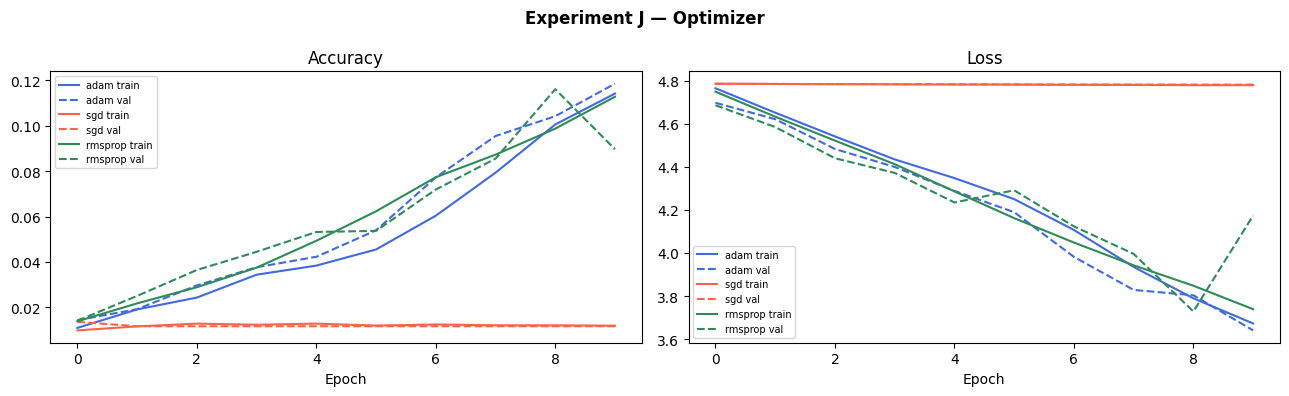

In [ ]:
plot_comparison(
    list(opt_history.values()),
    list(opt_history.keys()),
    'Experiment J — Optimizer'
)

## **Experiment K — Dense Units: 64 vs 128 vs 256**

**Hypothesis:** 128 units will be the sweet spot. 64 may
underfit — too little capacity in the classification head
for 120 classes. 256 may overfit slightly. Since GAP already
reduces parameters heavily, the dense layer size will have
less impact than expected.

In [ ]:
dense_history ={}
dense_acc={}

for units in [64,128,256]:
  tf.keras.backend.clear_session()
  print(f'Training dense_units={units}')
  model=build_model(dense_units=units)
  h,acc,t=train_model(model,train_data)
  dense_history[units]=h
  dense_acc[units]=acc


Training dense_units=64
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 84s 150ms/step - accuracy: 0.0109 - loss: 4.7860 - val_accuracy: 0.0117 - val_loss: 4.7846
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0135 - loss: 4.7746 - val_accuracy: 0.0138 - val_loss: 4.7770
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.0166 - loss: 4.6870 - val_accuracy: 0.0168 - val_loss: 4.6536
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0200 - loss: 4.6237 - val_accuracy: 0.0204 - val_loss: 4.5944
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.0259 - loss: 4.5438 - val_accuracy: 0.0221 - val_loss: 4.5386
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.0322 - loss: 4.4616 - val_accuracy: 0.0364 - val_loss: 4.4277
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - accuracy: 0.0373 - loss: 4.3640 - val_accuracy: 0.0452 - val_loss: 4.3165
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy:

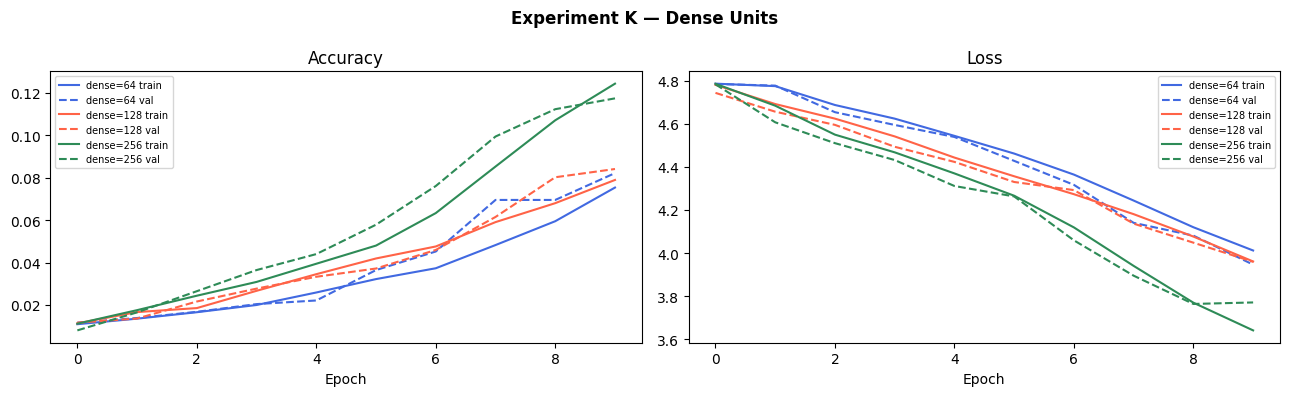

In [ ]:
plot_comparison(
    list(dense_history.values()),
    [f'dense={u}' for u in dense_history.keys()],
    'Experiment K — Dense Units'
)

## **Experiment K — Results**

| Dense Units | Val Accuracy | Train Accuracy | Overfitting |
|---|---|---|---|
| 64 | 8.21% | 7.53% | minimal |
| 128 | 8.41% | 7.89% | minimal |
| 256 | 11.73% | 12.43% | slight |

**Result: hypothesis rejected — 256 wins, not 128**

## What I observed-------------------->

256 units wins clearly at 11.73% both train and val
accuracy grow fastest and loss drops steepest.

64 and 128 perform almost identically — 8.21% vs 8.41%.
Too few units in the classification head limits the
model's ability to map 256 GAP features to 120 classes.

256 units starts showing a slight train-val gap by
epoch 10 (train loss still dropping while val loss
flattens) — mild overfitting beginning to appear
but not severe.

## Why 256 works better----------------->

GAP outputs 256 values (one per filter from the last
conv block).
 A dense layer of 256 units gives a
1-to-1 mapping before the final 120 class output  
enough capacity to learn the breed specific
combinations without being too large to overfit.

64 and 128 create a bottleneck compressing 256
features into fewer units before classification
loses information.

## What this tells us-------------------->

In this architecture, a dense layer of 256 units performed best.
This suggests that reducing the 256 GAP features to 64 or 128 units introduced an information bottleneck.

## Notebook 5 — All Results

| Experiment | Config | Val Accuracy |
|---|---|---|
| H | lr=0.01 | 1.17% — dead |
| H | lr=0.001 | 12.63% — winner |
| H | lr=0.0001 | 4.69% — too slow |
| I | batch=16 | 6.46% |
| I | batch=32 | 1.17% — dead |
| I | batch=64 | 9.62% — winner |
| I | batch=128 | 8.58% |
| J | Adam | 11.86% — winner |
| J | SGD | 1.36% — dead |
| J | RMSprop | 11.61% — unstable |
| K | dense=64 | 8.21% |
| K | dense=128 | 8.41% |
| K | dense=256 | 11.73% — winner |

## How much does hyperparameter tuning actually matter?

*Best config from this notebook:
lr=0.001, batch=64, Adam, dense=256*

*None of these individual experiments beat notebook 4's
13.41%. Manual tuning one parameter at a time found
useful settings but couldn't surpass the combined
architecture + regularization decisions.*

*This confirms the notebook's central question —>
hyperparameter tuning matters, but architecture
and regularization choices matter more*

------------------------------------------
##**Best config going into Optuna:
   lr=0.001, batch=64, Adam, dense=256, dropout=0.2,
   basic augmentation, 4 conv layers, GAP, 32→64→128→256**

------------------------------------------

##**Current best: 13.41% val accuracy**
**Moving to notebook 6 — Optuna automated search**